In [1]:
# PIP MODE: use the installed ras-commander package.
# For local source testing, run Jupyter with PYTHONPATH set to the repo root.

from pathlib import Path
import logging

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from shapely.geometry import box

from ras_commander import RasExamples, RasMap, RasCmdr, RasPlan, init_ras_project
from ras_commander.hdf import HdfLandCover

for logger_name in [
    "ras_commander.RasExamples",
    "ras_commander.RasMap",
    "ras_commander._land_classification_helper",
    "ras_commander.hdf.HdfBase",
    "ras_commander.hdf.HdfLandCover",
    "ras_commander.RasPlan",
]:
    logging.getLogger(logger_name).setLevel(logging.WARNING)

## Developer Mode

When editing ras-commander locally, run this notebook from the repository root with `PYTHONPATH` set to that root before launching Jupyter or `nbconvert`. Restore this pip-mode import cell before committing.

# Land Classification Polygon Authoring

This notebook demonstrates the complete pipeline for adding land-cover
classification polygon overrides to a HEC-RAS 2D project and verifying they
take effect through geometry preprocessing:

1. Read the existing per-cell Manning's n (**before** snapshot)
2. Write override polygons to the project's sidecar HDF
3. Verify the sidecar association with the geometry
4. Run geometry preprocessing (geometry only -- no unsteady solve)
5. Read the updated per-cell Manning's n (**after** snapshot)
6. Compare before and after to verify the overrides took effect

In [2]:
PROJECT_NAME = "BaldEagleCrkMulti2D"
PLAN_NUMBER = "03"
MESH_NAME = "BaldEagleCr"

# Extract a fresh project (suffix avoids folder conflicts with other notebooks)
project_path = RasExamples.extract_project(PROJECT_NAME, suffix="213")
prj = init_ras_project(project_path, ras_version="6.6")

# Resolve geometry HDF from plan_df (DataFrame-first — no hardcoded base name)
plan_row = prj.plan_df[prj.plan_df["plan_number"] == PLAN_NUMBER].iloc[0]
geom_number = plan_row["geometry_number"]
geom_path = prj.geom_df.loc[
    prj.geom_df["geom_number"] == geom_number, "full_path"
].iloc[0]
geom_hdf = Path(str(geom_path) + ".hdf")

# --- BEFORE snapshot: per-cell Manning's n from the preprocessed geometry ---
before_df = HdfLandCover.get_preprocessed_mannings_n(geom_hdf)
before_n = before_df["mannings_n"].values

with h5py.File(str(geom_hdf), "r") as f:
    centers = f[f"Geometry/2D Flow Areas/{MESH_NAME}/Cells Center Coordinate"][:]

print(f"Project:      {project_path}")
print(f"Plan p{PLAN_NUMBER}:     {plan_row['Plan Title']}")
print(f"Geometry HDF: {geom_hdf.name}")
print(f"Mesh:         {MESH_NAME}  ({len(before_n)} cells)")
print(f"Before n:     [{before_n.min():.4f}, {before_n.max():.4f}]")
print(f"Unique values: {np.unique(before_n)}")

2026-05-16 23:17:42 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


2026-05-16 23:17:42 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-05-16 23:17:42 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.5 at C:\Program Files (x86)\HEC\HEC-RAS\6.5\Ras.exe via filesystem (x86)


2026-05-16 23:17:42 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.3.1 at C:\Program Files (x86)\HEC\HEC-RAS\6.3.1\Ras.exe via filesystem (x86)


2026-05-16 23:17:42 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.2 at C:\Program Files (x86)\HEC\HEC-RAS\6.2\Ras.exe via filesystem (x86)


...

2026-05-16 23:17:43 - ras_commander.RasPrj - INFO - Updated results_df with 11 plan(s)


2026-05-16 23:17:43 - ras_commander.RasPrj - INFO - ras-commander v0.96.2 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://ras-commander.readthedocs.io | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-05-16 23:17:43 - ras_commander.RasPrj - INFO - Project initialized: BaldEagleDamBrk | Folder: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_213


2026-05-16 23:17:43 - ras_commander.RasPrj - INFO - Using HEC-RAS executable: C:\Program Files (x86)\HEC\HEC-RAS\6.6\Ras.exe


Project:      G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_213
Plan p03:     Single 2D Area - Internal Dam Structure
Geometry HDF: BaldEagleDamBrk.g09.hdf
Mesh:         BaldEagleCr  (19597 cells)
Before n:     [0.0300, 0.1500]
Unique values: [0.03       0.035      0.04       0.045      0.05       0.06
 0.08       0.1        0.12       0.15000001]


In [3]:
# Discover the project's land-cover sidecar
landcover_layers = RasMap.list_landcover_layers(project_path)
assert not landcover_layers.empty, "No land-cover layer found in project."
source_hdf = Path(landcover_layers.iloc[0]["resolved_path"])

# Read the existing land-cover class table
class_map = HdfLandCover.get_landcover_raster_map(source_hdf)
print("Existing land-cover classes:")
display(class_map)

# Override specs using EXISTING class names that already have entries in all
# dependent sidecar layers (Infiltration, Soils).  This avoids "Curve Number
# has no value" errors during preprocessing.
#
# Strategy:
#   Polygon 1 — Reclassify a mixed-use area to "Barren Land Rock-Sand-Clay"
#               (n=0.030), producing a large DECREASE in roughness.
#   Polygon 2 — Reclassify a developed/grassland area to "Evergreen Forest"
#               (n=0.150), producing a large INCREASE in roughness.

override_specs = [
    {
        "class_name": "Barren Land Rock-Sand-Clay",
        "class_id": 31,
        "mannings_n": 0.030,
        "percent_impervious": 0.0,
        "geometry": box(2025068, 332903, 2036934, 341036),
    },
    {
        "class_name": "Evergreen Forest",
        "class_id": 42,
        "mannings_n": 0.150,
        "percent_impervious": 0.0,
        "geometry": box(1990000, 310000, 2005000, 320000),
    },
]

# Identify cells within each polygon and record their BEFORE n-values
before_by_polygon = {}
for spec in override_specs:
    bminx, bminy, bmaxx, bmaxy = spec["geometry"].bounds
    mask = (
        (centers[:, 0] >= bminx) & (centers[:, 0] <= bmaxx)
        & (centers[:, 1] >= bminy) & (centers[:, 1] <= bmaxy)
    )
    before_by_polygon[spec["class_name"]] = {
        "mask": mask,
        "cell_count": int(mask.sum()),
        "mean_n_before": float(before_n[mask].mean()) if mask.sum() > 0 else 0.0,
        "target_n": spec["mannings_n"],
    }
    print(
        f"\n{spec['class_name']}: {mask.sum()} cells, "
        f"current mean n={before_n[mask].mean():.4f}, "
        f"target n={spec['mannings_n']:.3f}"
    )

print(f"\nSidecar HDF: {source_hdf}")

Existing land-cover classes:


,pixel_value,class_name,mannings_n
0,0,NoData,0.035
1,43,Mixed Forest,0.120
2,41,Deciduous Forest,0.100
3,21,"Developed, Open Space",0.035
4,42,Evergreen Forest,0.150
5,11,Open Water,0.035
6,52,Shrub-Scrub,0.050
7,81,Pasture-Hay,0.045
8,71,Grassland-Herbaceous,0.040
9,82,Cultivated Crops,0.050



Barren Land Rock-Sand-Clay: 1154 cells, current mean n=0.0653, target n=0.030

Evergreen Forest: 1644 cells, current mean n=0.0573, target n=0.150

Sidecar HDF: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_213\Land Classification\LandCover.hdf


## Write Override Polygons to Project Sidecar

`RasMap.add_land_classification_polygon()` writes classification polygon
records into the sidecar HDF's `Classification Polygons/` group and upserts
class rows in `Raster Map` and `Variables`.  It returns a GeoDataFrame with
a `recompute_required=True` attribute signaling that geometry preprocessing
must re-run before the overrides take effect in a simulation.

We use **existing** class names ("Barren Land Rock-Sand-Clay" and
"Evergreen Forest") that already have matching entries in the project's
infiltration sidecar.  This avoids "Curve Number has no value" errors
during preprocessing on projects that use SCS Curve Number infiltration.

In [4]:
# Write overrides to the PROJECT'S ACTUAL sidecar HDF
last_result = None
for spec in override_specs:
    last_result = RasMap.add_land_classification_polygon(
        source_hdf,
        spec["geometry"],
        class_name=spec["class_name"],
        class_id=spec["class_id"],
        variable_values={
            "mannings_n": spec["mannings_n"],
            "percent_impervious": spec["percent_impervious"],
        },
    )

assert last_result is not None
assert last_result.attrs["recompute_required"] is True

# Verify what was written
polygons = HdfLandCover.get_classification_polygons(source_hdf)
class_map_after = HdfLandCover.get_landcover_raster_map(source_hdf)
created_names = [s["class_name"] for s in override_specs]

print(f"Sidecar HDF: {source_hdf}")
print(f"Classification polygons written: {len(polygons)}")
print(f"Recompute required: {last_result.attrs['recompute_required']}")
print(f"\nOverride classes in Raster Map:")
display(class_map_after.loc[class_map_after["class_name"].isin(created_names)])

Sidecar HDF: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_213\Land Classification\LandCover.hdf
Classification polygons written: 3
Recompute required: True

Override classes in Raster Map:


,pixel_value,class_name,mannings_n
6,31,Barren Land Rock-Sand-Clay,0.03
8,42,Evergreen Forest,0.15


## Verify Sidecar Association and Run Geometry Preprocessor

The BaldEagleCrkMulti2D project already has its land-cover sidecar
associated with the geometry HDF via the `Land Cover Filename` attribute.
We verify this association exists before running the preprocessor.

We use `RasCmdr.compute_plan()` with the plan temporarily reconfigured to
force geometry preprocessing (`Run HTab=-1`) and skip everything else
(unsteady compute, post-processing, floodplain mapping all set to 0).
Combined with `clear_geompre=True`, this forces HEC-RAS to resample **all**
land-cover layers — including our classification polygon overrides — into
per-cell Manning's n values stored in the geometry HDF.

In [5]:
# Verify the existing land-cover sidecar association
lc_assoc = HdfLandCover.get_landcover_association(geom_hdf)
print(f"Geometry HDF land cover association: {lc_assoc}")
assert lc_assoc is not None and str(lc_assoc).strip(), (
    "No land-cover association found -- call RasMap.associate_geometry_layers() first."
)

# --- Temporarily reconfigure plan for geometry-only preprocessing ---
plan_path = Path(RasPlan.get_plan_path(PLAN_NUMBER, ras_object=prj))
original_plan_text = plan_path.read_text(encoding="utf-8", errors="ignore")

# Force geometry preprocessor to recompute hydraulic tables
RasPlan.set_geom_preprocessor(plan_path, run_htab=-1, use_ib_tables=-1, ras_object=prj)

# Disable unsteady compute, post-processing, and floodplain mapping
flags_to_disable = {"Run UNet": "0", "Run PostProcess": "0", "Run RASMapper": "0"}
lines = plan_path.read_text(encoding="utf-8", errors="ignore").splitlines(keepends=True)
patched = []
for line in lines:
    stripped = line.lstrip()
    replaced = False
    for key, value in flags_to_disable.items():
        if stripped.startswith(f"{key}="):
            prefix = line[: len(line) - len(stripped)]
            patched.append(f"{prefix}{key}= {value} \n")
            replaced = True
            break
    if not replaced:
        patched.append(line)
plan_path.write_text("".join(patched), encoding="utf-8")

print(f"Running geometry preprocessing for Plan {PLAN_NUMBER}...")
geom_hdf_mtime = geom_hdf.stat().st_mtime

try:
    RasCmdr.compute_plan(PLAN_NUMBER, ras_object=prj, clear_geompre=True)
finally:
    plan_path.write_text(original_plan_text, encoding="utf-8")

assert geom_hdf.stat().st_mtime > geom_hdf_mtime, (
    "Geometry HDF was not updated — preprocessing may have failed."
)
print("Geometry preprocessing complete — plan file restored.")

2026-05-16 23:17:43 - ras_commander.RasUtils - INFO - Successfully updated file: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_213\BaldEagleDamBrk.p03


Geometry HDF land cover association: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_213\Land Classification\LandCover.hdf


2026-05-16 23:17:43 - ras_commander.RasCmdr - INFO - Using ras_object with project folder: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_213


2026-05-16 23:17:43 - ras_commander.geom.GeomPreprocessor - INFO - Clearing geometry preprocessor file for single plan: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_213\BaldEagleDamBrk.p03


2026-05-16 23:17:43 - ras_commander.geom.GeomPreprocessor - INFO - Deleted geometry preprocessor file: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_213\BaldEagleDamBrk.c09


...

2026-05-16 23:17:59 - ras_commander.hdf.HdfResultsPlan - INFO - Simulation Duration (hours): 72.0


2026-05-16 23:17:59 - ras_commander.hdf.HdfResultsPlan - INFO - Using existing Path object HDF file: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_213\BaldEagleDamBrk.p03.hdf


2026-05-16 23:17:59 - ras_commander.hdf.HdfResultsPlan - INFO - Final validated file path: G:\GH\ras-commander\examples\example_projects\BaldEagleCrkMulti2D_213\BaldEagleDamBrk.p03.hdf


2026-05-16 23:17:59 - ras_commander.RasPrj - INFO - Updated results_df with 1 plan(s)


Geometry preprocessing complete — plan file restored.


## Read Updated Per-Cell Manning's n

The geometry preprocessor has resampled the land-cover raster — including
our two classification polygon overrides — into per-cell roughness values
stored in the geometry HDF.  Cells whose centers fall within the override
polygon footprints should now reflect the target class Manning's n values.

In [6]:
# --- AFTER snapshot: per-cell Manning's n from the reprocessed geometry ---
after_df = HdfLandCover.get_preprocessed_mannings_n(geom_hdf)
after_n = after_df["mannings_n"].values

print(f"After n:       [{after_n.min():.4f}, {after_n.max():.4f}]")
print(f"Unique values: {np.unique(after_n)}")

# Before/After comparison within override footprints
print("\nBefore / After comparison within override footprints:\n")
print(
    f"{'Override Class':<30s} {'Cells':>6s} "
    f"{'Before Mean':>12s} {'After Mean':>11s} {'Target':>8s} {'Delta':>8s}"
)
print("-" * 80)
for spec in override_specs:
    info = before_by_polygon[spec["class_name"]]
    mask = info["mask"]
    if mask.sum() == 0:
        continue
    mean_before = before_n[mask].mean()
    mean_after = after_n[mask].mean()
    target = spec["mannings_n"]
    delta = mean_after - mean_before
    print(
        f"{spec['class_name']:<30s} {info['cell_count']:>6d} "
        f"{mean_before:>12.4f} {mean_after:>11.4f} {target:>8.3f} {delta:>+8.4f}"
    )

changed_mask = ~np.isclose(before_n, after_n, atol=1e-6)
print(f"\nTotal cells changed: {changed_mask.sum()} / {len(before_n)}")
print(f"Cells unchanged:     {(~changed_mask).sum()}")

After n:       [0.0300, 0.1500]
Unique values: [0.03       0.035      0.04       0.045      0.05       0.06
 0.08       0.1        0.12       0.15000001]

Before / After comparison within override footprints:

Override Class                  Cells  Before Mean  After Mean   Target    Delta
--------------------------------------------------------------------------------
Barren Land Rock-Sand-Clay       1154       0.0653      0.0300    0.030  -0.0353
Evergreen Forest                 1644       0.0573      0.1184    0.150  +0.0610

Total cells changed: 2740 / 19597
Cells unchanged:     16857


C:\Users\bill\AppData\Local\Temp\ipykernel_36604\1148041846.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


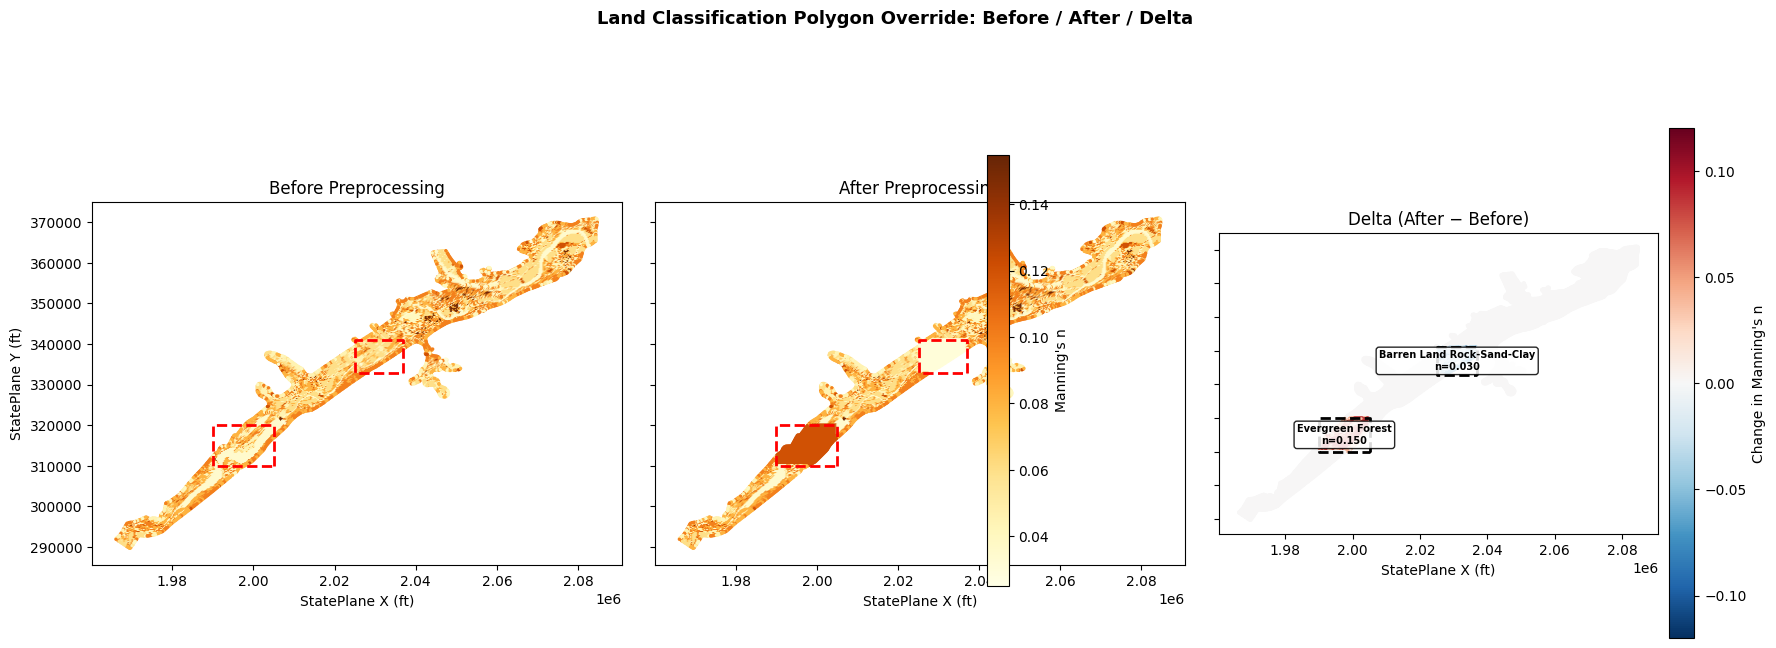

In [7]:
delta_n = after_n - before_n
vmin, vmax = 0.025, 0.155

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharex=True, sharey=True)

# --- Panel 1: Before ---
ax = axes[0]
sc0 = ax.scatter(
    centers[:, 0], centers[:, 1], c=before_n,
    cmap="YlOrBr", s=2, vmin=vmin, vmax=vmax,
)
for spec in override_specs:
    ex_x, ex_y = spec["geometry"].exterior.xy
    ax.plot(ex_x, ex_y, color="red", linewidth=2, linestyle="--")
ax.set_title("Before Preprocessing")
ax.set_ylabel("StatePlane Y (ft)")
ax.set_aspect("equal")

# --- Panel 2: After ---
ax = axes[1]
sc1 = ax.scatter(
    centers[:, 0], centers[:, 1], c=after_n,
    cmap="YlOrBr", s=2, vmin=vmin, vmax=vmax,
)
for spec in override_specs:
    ex_x, ex_y = spec["geometry"].exterior.xy
    ax.plot(ex_x, ex_y, color="red", linewidth=2, linestyle="--")
ax.set_title("After Preprocessing")
ax.set_aspect("equal")

cbar = fig.colorbar(sc1, ax=axes[:2].tolist(), shrink=0.8, pad=0.02)
cbar.set_label("Manning's n")

# --- Panel 3: Delta ---
ax = axes[2]
dmax = max(abs(delta_n.min()), abs(delta_n.max()), 0.01)
sc2 = ax.scatter(
    centers[:, 0], centers[:, 1], c=delta_n,
    cmap="RdBu_r", s=2, vmin=-dmax, vmax=dmax,
)
for spec in override_specs:
    ex_x, ex_y = spec["geometry"].exterior.xy
    ax.plot(ex_x, ex_y, color="black", linewidth=2, linestyle="--")
    cx, cy = spec["geometry"].centroid.coords[0]
    ax.annotate(
        f"{spec['class_name']}\nn={spec['mannings_n']:.3f}",
        xy=(cx, cy), ha="center", va="center", fontsize=7,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85),
    )
ax.set_title("Delta (After − Before)")
ax.set_aspect("equal")
cbar2 = fig.colorbar(sc2, ax=axes[2], shrink=0.8, pad=0.02)
cbar2.set_label("Change in Manning's n")

for ax in axes:
    ax.set_xlabel("StatePlane X (ft)")

fig.suptitle(
    "Land Classification Polygon Override: Before / After / Delta",
    fontsize=13, fontweight="bold", y=1.01,
)
fig.tight_layout()
plt.show()

In [8]:
# Audit the sidecar HDF structure after writing
def _decode(value):
    return value.decode("utf-8").strip() if isinstance(value, bytes) else value

with h5py.File(source_hdf, "r") as hdf_file:
    polygon_attrs = hdf_file["Classification Polygons/Attributes"][()]
    polygon_info = hdf_file["Classification Polygons/Polygon Info"][()]
    polygon_points = hdf_file["Classification Polygons/Polygon Points"][()]
    variables = hdf_file["Variables"][()]
    raster_map = hdf_file["Raster Map"][()]

audit = pd.DataFrame([
    {"dataset": "Classification Polygons/Attributes", "rows": len(polygon_attrs)},
    {"dataset": "Classification Polygons/Polygon Info", "rows": len(polygon_info)},
    {"dataset": "Classification Polygons/Polygon Points", "rows": len(polygon_points)},
    {"dataset": "Raster Map", "rows": len(raster_map)},
    {"dataset": "Variables", "rows": len(variables)},
])
print("Sidecar HDF dataset summary:")
display(audit)

print("\nClassification polygon classes:")
display(pd.DataFrame({
    "polygon_class": [_decode(row["Classification"]) for row in polygon_attrs]
}))

Sidecar HDF dataset summary:


,dataset,rows
0,Classification Polygons/Attributes,3
1,Classification Polygons/Polygon Info,3
2,Classification Polygons/Polygon Points,728
3,Raster Map,16
4,Variables,17



Classification polygon classes:


,polygon_class
0,Main Channel
1,Barren Land Rock-Sand-Clay
2,Evergreen Forest


In [9]:
# Final verification: Manning's n within each polygon moved toward target
for spec in override_specs:
    info = before_by_polygon[spec["class_name"]]
    mask = info["mask"]
    if mask.sum() == 0:
        continue
    mean_before = before_n[mask].mean()
    mean_after = after_n[mask].mean()
    target = spec["mannings_n"]

    # Direction check: after mean should be closer to target than before mean
    distance_before = abs(mean_before - target)
    distance_after = abs(mean_after - target)
    print(
        f"{spec['class_name']}: "
        f"before={mean_before:.4f}, after={mean_after:.4f}, target={target:.3f}  "
        f"(distance: {distance_before:.4f} -> {distance_after:.4f})"
    )
    assert distance_after < distance_before, (
        f"Manning's n did not move toward target for {spec['class_name']}"
    )

total_changed = int((~np.isclose(before_n, after_n, atol=1e-6)).sum())
assert total_changed > 0, "No cells changed after preprocessing"
print(f"\nVerification passed: {total_changed} cells changed by override polygons")

Barren Land Rock-Sand-Clay: before=0.0653, after=0.0300, target=0.030  (distance: 0.0353 -> 0.0000)
Evergreen Forest: before=0.0573, after=0.1184, target=0.150  (distance: 0.0927 -> 0.0316)

Verification passed: 2740 cells changed by override polygons
